<h1>Train — AlexNet</h1>

Trains and evaluates AlexNet **from scratch (no ImageNet pretraining)** using the hand-picked hyperparameters from `ARCH_HYPERPARAMS["alexnet"]`, then saves its results and weights to disk for the results notebook. Unlike every other architecture here, this one starts from random weights instead of a pretrained backbone -- included to see how a small CNN trained from scratch on this dataset compares to the transfer-learning models.

In [1]:
from wwtw_utils import *

Using device: cuda
Test set ID (derived from DATASET_ROOT): Fisantekraal
Classes found (4): ['Dysfunctional', 'Empty', 'Functional', 'Scum']
Train: 1814 | Val: 441 | Test: 252


## Build dataloaders + class weights for this architecture

In [2]:
cfg = ARCH_HYPERPARAMS["alexnet"]

# The tuned batch size (cfg["batch_size"]) can be too large to fit in GPU
# memory for a deeper model like this one, even though it fit fine for
# whichever model the tuning trials actually ran on. Rather than hard-coding
# a smaller batch size (and drifting from the tuned hyperparameters), cap the
# *actual* loader batch size at MICRO_BATCH_CAP and use gradient accumulation
# in train_model to still reach the tuned effective batch size.
micro_batch = min(cfg["batch_size"], MICRO_BATCH_CAP)
accum_steps = max(1, round(cfg["batch_size"] / micro_batch))
print(f"AlexNet: micro batch = {micro_batch}, accumulation steps = {accum_steps} "
      f"(effective batch size ≈ {micro_batch * accum_steps}, tuned value = {cfg['batch_size']})")

# This backbone gets its own dataloaders — its own (capped) batch size, and
# (for InceptionNet v3) its own image size.
train_ds_arch, val_ds_arch, test_ds_arch, train_loader_arch, val_loader_arch, test_loader_arch = \
    get_dataloaders(cfg["img_size"], micro_batch)

class_weights_arch = make_class_weights(train_ds_arch)

AlexNet: micro batch = 16, accumulation steps = 2 (effective batch size ≈ 32, tuned value = 32)


## Define the model

In [3]:
# ---------------------------------------------------------
# Define the CNN (AlexNet, trained from scratch -- no pretrained weights)
# ---------------------------------------------------------
model = models.alexnet(weights=None)  # no ImageNet pretraining, unlike every other architecture here

# AlexNet's classifier is nn.Sequential(Dropout, Linear, ReLU, Dropout, Linear,
# ReLU, Linear) — swap out just the final Linear layer (index 6) for our
# (optionally deeper) classifier head, same as the fc/classifier swaps used
# for the other architectures.
in_f = model.classifier[6].in_features
model.classifier[6] = build_classifier_head(in_f, cfg["hidden_layers"], cfg["neurons"], num_classes)

model = model.to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights_arch)
optimizer = optim.Adam(
    model.parameters(),
    lr=cfg["lr"],
    betas=(cfg["beta1"], ADAM_BETA2),
    weight_decay=WEIGHT_DECAY,
)
# Step-based decay: LR x0.1 every Es epochs.
scheduler = StepLR(optimizer, step_size=cfg["step_size"], gamma=0.1)

## Train, then plot training curves

[AlexNet] Using gradient accumulation: 2 micro-batches per optimizer step (effective batch size ≈ micro_batch x 2).


[AlexNet] Epoch   1/100 | LR: 1.00e-03 | train loss 1.3887 acc 0.248 | val loss 1.3698 acc 0.327 *


[AlexNet] Epoch   2/100 | LR: 1.00e-03 | train loss 1.3156 acc 0.352 | val loss 1.2239 acc 0.469 *


[AlexNet] Epoch   3/100 | LR: 1.00e-03 | train loss 1.2260 acc 0.440 | val loss 1.0724 acc 0.463 *


[AlexNet] Epoch   4/100 | LR: 1.00e-03 | train loss 1.2562 acc 0.422 | val loss 1.0983 acc 0.467


...

[AlexNet] Epoch   9/100 | LR: 1.00e-03 | train loss 1.3513 acc 0.368 | val loss 1.2192 acc 0.497


[AlexNet] Epoch  10/100 | LR: 1.00e-03 | train loss 1.3284 acc 0.388 | val loss 1.3017 acc 0.465


[AlexNet] Epoch  11/100 | LR: 1.00e-03 | train loss 1.2620 acc 0.447 | val loss 1.4459 acc 0.293


[AlexNet] Epoch  12/100 | LR: 1.00e-03 | train loss 1.3320 acc 0.423 | val loss 1.1443 acc 0.458


[AlexNet] Epoch  13/100 | LR: 1.00e-03 | train loss 1.3383 acc 0.441 | val loss 1.2515 acc 0.410

[AlexNet] No val loss improvement for 10 epochs — stopping early at epoch 13.

[AlexNet] Restored best checkpoint (val loss = 1.0724)


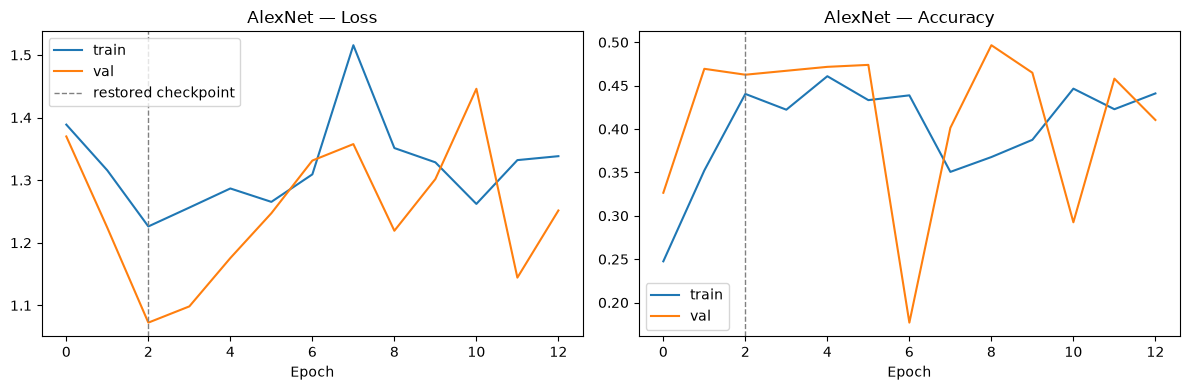

In [4]:
history = train_model(
    model, train_loader_arch, val_loader_arch, optimizer, scheduler,
    criterion, EPOCHS, EARLY_STOP_PATIENCE, "AlexNet", is_inception=False,
    accum_steps=accum_steps,
)
plot_training_curves(history, "AlexNet")

## Evaluate on the test set

[AlexNet] Test accuracy: 0.448


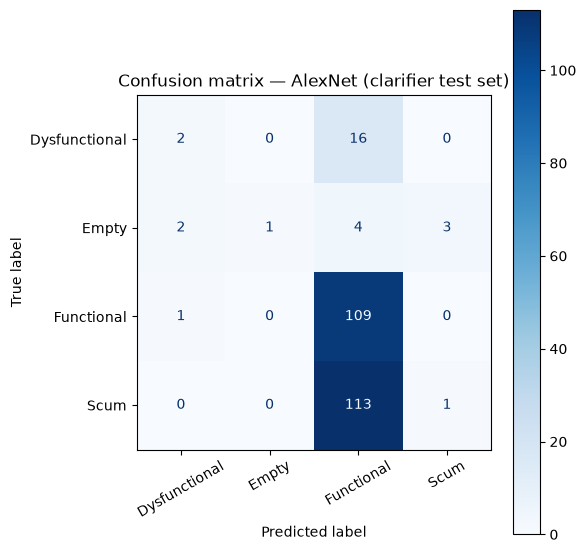

               precision    recall  f1-score   support

Dysfunctional      0.400     0.111     0.174        18
        Empty      1.000     0.100     0.182        10
   Functional      0.450     0.991     0.619       110
         Scum      0.250     0.009     0.017       114

     accuracy                          0.448       252
    macro avg      0.525     0.303     0.248       252
 weighted avg      0.378     0.448     0.298       252



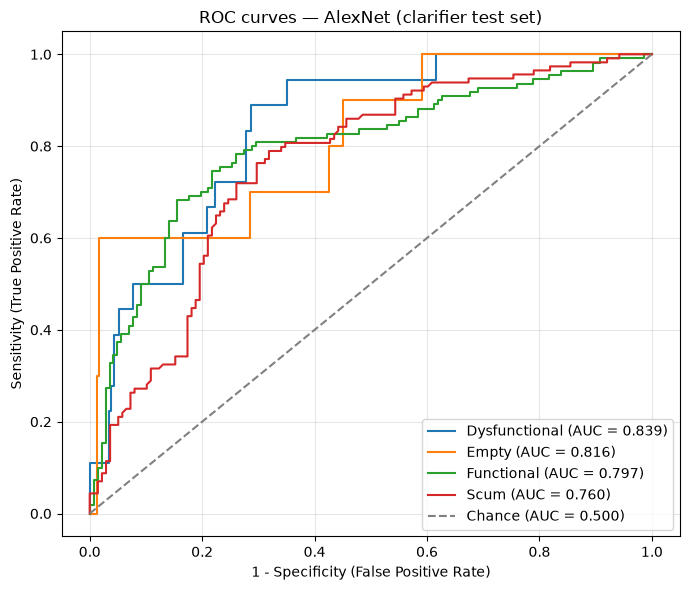

AUC (area under ROC curve) per class:
  Dysfunctional  : 0.839
  Empty          : 0.816
  Functional     : 0.797
  Scum           : 0.760

Mean AUC (over 4/4 classes with test examples): 0.803


(np.float64(0.44841269841269843),
 {'Dysfunctional': 0.8392687559354226,
  'Empty': 0.8161157024793388,
  'Functional': 0.7967349551856595,
  'Scum': 0.75988431222985})

In [5]:
evaluate_and_record(
    model, test_loader_arch, "AlexNet", history,
    img_size=cfg["img_size"], hidden_layers=cfg["hidden_layers"], neurons=cfg["neurons"],
)

## Save results + model weights to disk

In [6]:
save_result("AlexNet", "alexnet")

Saved results to ../results/results_clarifier_alexnet_Fisantekraal.pkl


Saved model weights to ../models/clarifier_alexnet_cnn.pt
